In [2]:
import math

class Value:
	data: float
	op: str
	grad: float
	prev: set['Value']

	def __init__(self, data: float, prev = (), op = ''):
		self.data = data
		self.prev = set(prev)
		self.grad = 0
		self.op=op
		self._backwards = lambda: None


	def __repr__(self):
		return f"Value: {self.data} (grad: {self.grad}, op: {self.op})"
	
	def __add__(self, o: 'Value') -> 'Value':
		val = self.data + o.data
		result = Value(val, prev=(self, o), op='+')
		def _backwards():
			self.grad += 1 * result.grad
			o.grad += 1 * result.grad
		result._backwards = _backwards
		return result
	
	def __sub__(self, o: 'Value') -> 'Value':
		val = self.data - o.data
		result = Value(val, prev=(self, o), op='-')
		def _backwards():
			self.grad += 1 * result.grad
			o.grad += -1 * result.grad
		result._backwards = _backwards
		return result
	
	def __mul__(self, o: 'Value') -> 'Value':
		val = self.data * o.data
		result = Value(val, prev=(self, o), op='*')
		def _backwards():
			self.grad += o.data * result.grad
			o.grad += self.data * result.grad
		result._backwards = _backwards
		return result
	
	def __pow__(self, o: int) -> 'Value':
		val = self.data ** o
		result = Value(val, prev=(self,), op=f"**{o}")
		def _backwards():
			self.grad += result.grad * o * self.data**(o-1)
		result._backwards = _backwards
		return result
	
	def activate(self) -> 'Value':
		val = math.tanh(self.data)
		result = Value(val, prev=(self,), op=f"tanh()")
		def _backwards():
			self.grad += result.grad * (1 - val * val)

		result._backwards = _backwards
		return result
	
	def backwards(self) -> None:
		topsort = []
		visited = set()
		def build_top(v: Value):
			if v not in visited:
				visited.add(v)
				for child in v.prev:
					build_top(child)
				topsort.append(v)
		build_top(self)
		self.grad = 1
		for v in reversed(topsort):
			v._backwards()


Value(2).backwards()





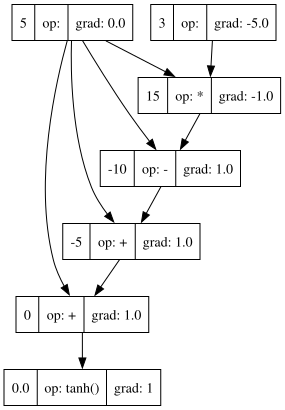

In [3]:
from graphviz import Digraph

def graph_value(v: Value) -> Digraph:
	graph = Digraph()
	def value_id(_v: Value) -> str:
		return str(id(_v))

	visited = set()
	nodes = [v]
	index = 0
	while index<len(nodes):
		at = nodes[index]
		graph.node(value_id(at), f"{at.data} | op: {at.op} | grad: {at.grad}", shape="record")
		for cameFrom in at.prev:
			graph.edge(value_id(cameFrom), value_id(at))
			if cameFrom in visited:
				continue
			visited.add(cameFrom)
			nodes.append(cameFrom)
		
		index+=1;
	return graph


a = Value(5)
b = Value(3)
c = a - b * a + a + a
d = c.activate()
d.backwards()

graph_value(d)


In [4]:
import random

class Neuron:
	def __init__(self, nin, nonlin = True):
		self.b=Value(0)
		self.w=[Value(random.uniform(-1, 1)) for _ in range(nin)]
		self.nonlin = nonlin

	def __call__(self, x):
		preact = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
		if self.nonlin:
			return preact.activate()
		return preact

	def parameters(self):
		return self.w+[self.b]
	
	def __repr__(self):
		return f"{'Sigmoid' if self.nonlin else 'Linear'}Neuron({len(self.w)})"
	
class Layer:
	def __init__(self, nin, nout, nonlin = True):
		self.neurons = [Neuron(nin, nonlin=nonlin) for _ in range(nout)]

	def __call__(self, x):
		outputs = [n(x) for n in self.neurons]
		return outputs
	
	def parameters(self):
		return [p for n in self.neurons for p in n.parameters()]
	
	def __repr__(self):
		return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
	
	def zerograd(self):
		for p in self.parameters():
			p.grad=0
	
class MLP:
	def __init__(self, sizes: list[int]):
		self.layers = [Layer(sizes[i], sizes[i+1], nonlin = i<len(sizes)-2) for i in range(len(sizes)-1)]

	def __repr__(self):
		return f"MLP of [{', '.join(str(l) for l in self.layers)}]"
	
	def __call__(self, x: list[Value]) -> list[Value]:
		for l in self.layers:
			x=l(x)
		return x
	
	def parameters(self):
		return [p for l in self.layers for p in l.parameters()]
	
	def zerograd(self):
		for p in self.parameters():
			p.grad=0

MLP([3, 5, 1])
	

MLP of [Layer of [SigmoidNeuron(3), SigmoidNeuron(3), SigmoidNeuron(3), SigmoidNeuron(3), SigmoidNeuron(3)], Layer of [LinearNeuron(5)]]

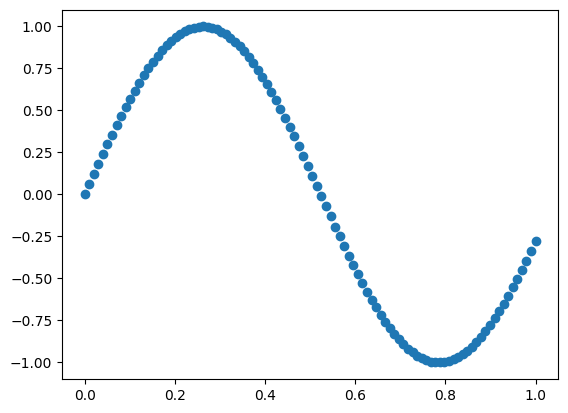

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def funToPredict(a: Value) -> Value:
	return Value(math.sin(6*a.data), op="ANSWER")


xs = np.linspace(0, 1, 100)
ys = np.array([funToPredict(Value(x)).data for x in xs])
plt.scatter(xs, ys)
plt.show()





In [6]:
mlp = MLP([1, 5, 5, 5, 1]);
# mlp = Layer(1, 1, nonlin=False)
len(mlp.parameters())

76

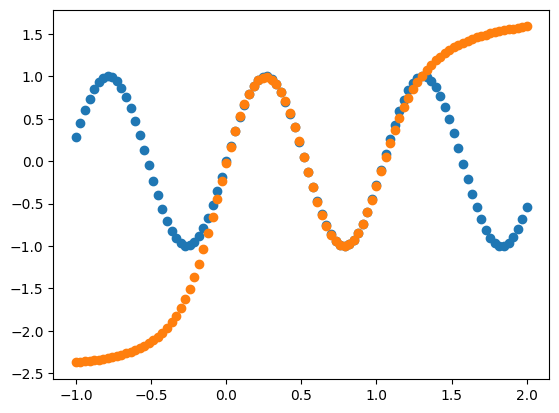

In [11]:
xs = np.linspace(-1, 2, 100)
predicted_ys=np.array([mlp([Value(x)])[0].data for x in xs])
ys = np.array([funToPredict(Value(x)).data for x in xs])
plt.scatter(xs, ys)
plt.scatter(xs, predicted_ys)
# plt.ylim(-5, 5)
plt.show()

Epoch 0 of 20000 (0.0%), Loss was 18.077010669742442
Epoch 1 of 20000 (0.005%), Loss was 11.858686059050957
Epoch 2 of 20000 (0.01%), Loss was 12.83914157725047
Epoch 3 of 20000 (0.015%), Loss was 9.162100339191259
Epoch 4 of 20000 (0.02%), Loss was 12.898264887164771
Epoch 5 of 20000 (0.025%), Loss was 9.596316001863045
Epoch 6 of 20000 (0.03%), Loss was 11.914525289063608
Epoch 7 of 20000 (0.035%), Loss was 7.01856677159162
Epoch 8 of 20000 (0.04%), Loss was 10.319414612188737
Epoch 9 of 20000 (0.045%), Loss was 6.623278958094314
Epoch 10 of 20000 (0.05%), Loss was 6.4861916104591995
Epoch 11 of 20000 (0.055%), Loss was 8.037254456933985
Epoch 12 of 20000 (0.06%), Loss was 8.486342354369285
Epoch 13 of 20000 (0.065%), Loss was 5.642482908529949
Epoch 14 of 20000 (0.07%), Loss was 6.6819239337816425
Epoch 15 of 20000 (0.075%), Loss was 7.2768427531512785
Epoch 16 of 20000 (0.08%), Loss was 5.374563673616206
Epoch 17 of 20000 (0.085%), Loss was 7.6239363783188585
Epoch 18 of 20000 (0.0

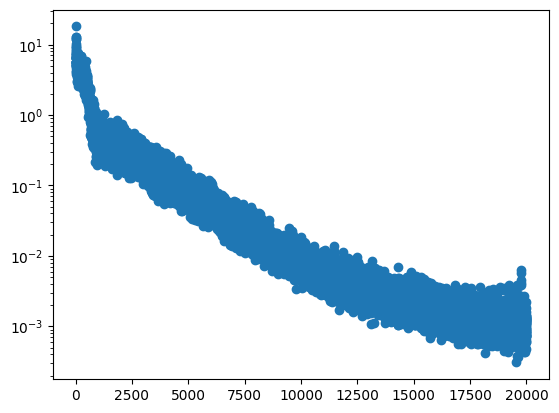

In [8]:
# We want to build a MLP to predict this funToPredict


def loss(batch_size: int) -> Value:

	batch_input = [random.uniform(0,1) for _ in range(batch_size)]
	# batch_input = np.linspace(0, 1, batch_size)
	true_outputs = [funToPredict(Value(sample_input)) for sample_input in batch_input]
	predicted_outputs = [mlp([Value(sample_input, op="INPUT")])[0] for sample_input in batch_input]

	loss = sum([(true_output-predicted_output) ** 2 for true_output, predicted_output in zip(true_outputs, predicted_outputs)], Value(0))
	return loss
	

epochs = 20000
batch_size = 30
# learning_rates = np.linspace(0.001, 0, epochs);
learning_rate = 0.001
losses = []
for epoch in range(epochs):
	l = loss(batch_size=batch_size)
	losses.append(l.data)
	mlp.zerograd()
	l.backwards()
	# graph_value(l)

	print(f"Epoch {epoch} of {epochs} ({epoch*100./epochs}%), Loss was {l.data}")
	# learning_rate = learning_rates[round];
	for p in mlp.parameters():
		p.data -= p.grad * learning_rate

	if epoch < 200 or epoch % 100 == 0:
		xs = np.linspace(0, 1, 100)
		predicted_ys=np.array([mlp([Value(x)])[0].data for x in xs])
		ys = np.array([funToPredict(Value(x)).data for x in xs])
		plt.scatter(xs, ys)
		plt.scatter(xs, predicted_ys)
		plt.title(f'Epoch {epoch}')
		plt.savefig(f'progress/plot{epoch:05}.png')
		plt.close()




# xs = np.linspace(0, 1, 100)
# predicted_ys=np.array([mlp([Value(x)])[0].data for x in xs])
# ys = np.array([funToPredict(Value(x)).data for x in xs])
# plt.scatter(xs, ys)
# plt.scatter(xs, predicted_ys)
# plt.ylim(-5, 5)
# plt.show()

plt.scatter(np.linspace(1, epochs, epochs), losses)
plt.yscale('log')



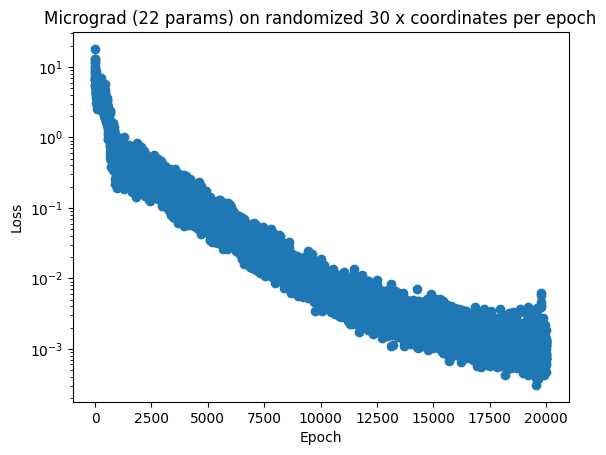

In [9]:
plt.scatter(np.linspace(1, epochs, epochs), losses)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Micrograd (22 params) on randomized 30 x coordinates per epoch')
plt.show()


In [10]:
from PIL import Image
import glob

files = sorted(glob.glob("progress/*.png"))

frames = [Image.open(file) for file in files]

frames[0].save(
    "animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100,   # milliseconds per frame
    loop=0          # 0 = loop forever
)